# Addressing comment R3C3 - beacon data

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd

In [3]:
import os, sys
from scipy.sparse import issparse
import gc

In [4]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [5]:
sc.settings.set_figure_params(frameon=False, figsize=(10, 10))

In [6]:
initDir = '/nfs/team361/ms83/data/skin/xenium_mintflow/analysis/'

In [7]:
adata = sc.read_h5ad(initDir + 'adata_10ad_spatial_V2.h5ad')

In [8]:
adata

AnnData object with n_obs × n_vars = 197483 × 1032
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', 'Site_status', 'info_id', 'sample', 'niche_name', 'lvl1', 'lvl0', 'veryfine_celltypes_new5', 'veryfine_celltypes_new5_incprolif', 'veryfine_celltypes', 'fine_celltypes_new', 'mod_celltypes_new', 'broad_celltypes_new', 'Site_status_binary', 'fine_celltypes', 'broad_celltypes', 'n_counts', 'n_genes', 'inflow_cell_type', 'inflow_biological_batch_ID', 'inflow_slice_ID', 'inflow_signaling_activity', 'leiden_res0.8', 'leiden_res0.5', 'NICHE_NAMES', 'spatial_niche', 'key_celltype_new', 'leiden_Z_0.5', 'mintflow_spatial_niche', 'leiden_intrinsic_res0.5'
    uns: 'NICHE_NAMES_colors', 'X_PCA_

In [9]:
adata_X = sc.read_h5ad(initDir + 'adata_10ad_spatial_leiden05_Xemb_V2_for_nichecompass.h5ad')
adata_X

AnnData object with n_obs × n_vars = 197483 × 1032
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', 'Site_status', 'info_id', 'sample', 'niche_name', 'lvl1', 'lvl0', 'veryfine_celltypes_new5', 'veryfine_celltypes_new5_incprolif', 'veryfine_celltypes', 'fine_celltypes_new', 'mod_celltypes_new', 'broad_celltypes_new', 'Site_status_binary', 'fine_celltypes', 'broad_celltypes', 'n_counts', 'n_genes', 'inflow_cell_type', 'inflow_biological_batch_ID', 'inflow_slice_ID', 'inflow_signaling_activity', 'leiden_res0.8', 'leiden_res0.5', 'NICHE_NAMES', 'spatial_niche', 'key_celltype_new', 'leiden_X_res0.8', 'leiden_X_res0.5', 'mintflow_spatial_niche', 'leiden_expression_res0.5'
    uns: 'NICHE

In [10]:
common = adata.obs_names.intersection(adata_X.obs_names)
common

Index(['aaaebhjc-1_BK23_Lesional Baseline',
       'aaaeoajc-1_BK23_Lesional Baseline',
       'aaagclgd-1_BK23_Lesional Baseline',
       'aaagpmeb-1_BK23_Lesional Baseline',
       'aaakcdpa-1_BK23_Lesional Baseline',
       'aaamakpn-1_BK23_Lesional Baseline',
       'aaambplb-1_BK23_Lesional Baseline',
       'aaanjkek-1_BK23_Lesional Baseline',
       'aaankioo-1_BK23_Lesional Baseline',
       'aababdag-1_BK23_Lesional Baseline',
       ...
       'oiiefnlo-1_BK18_Lesional Baseline',
       'oiiknljo-1_BK18_Lesional Baseline',
       'oiinpokd-1_BK18_Lesional Baseline',
       'oilfihka-1_BK18_Lesional Baseline',
       'oilnhcme-1_BK18_Lesional Baseline',
       'oimeihoe-1_BK18_Lesional Baseline',
       'oimjlcgb-1_BK18_Lesional Baseline',
       'oinmkkeo-1_BK18_Lesional Baseline',
       'ojalakpp-1_BK18_Lesional Baseline',
       'ojbbolni-1_BK18_Lesional Baseline'],
      dtype='object', name='combined_index', length=197483)

In [11]:
adata_sub = adata[common].copy()
adataX_sub = adata_X[common].copy()

In [23]:
cell_type_key = "inflow_cell_type" 

def ari_nmi(obs_a, obs_b):
    a = obs_a.astype(str).values
    b = obs_b.astype(str).values
    return {
        "ARI": adjusted_rand_score(a, b),
        "NMI": normalized_mutual_info_score(a, b),
    }

scores_ct = []

# microenvironment clusters (MintFlow niches)
scores_ct.append({
    "embedding": "microenv (MintFlow niches)",
    **ari_nmi(adata_sub.obs[cell_type_key], adata_sub.obs["mintflow_spatial_niche"])
})

# intrinsic clusters
scores_ct.append({
    "embedding": "intrinsic (Leiden res=0.5)",
    **ari_nmi(adata_sub.obs[cell_type_key], adata_sub.obs["leiden_intrinsic_res0.5"])
})

# raw expression clusters (from adata_X)
scores_ct.append({
    "embedding": "raw expression (Leiden res=0.5)",
    **ari_nmi(adataX_sub.obs[cell_type_key], adataX_sub.obs["leiden_expression_res0.5"])
})

df_ari_nmi = pd.DataFrame(scores_ct)
df_ari_nmi

,embedding,ARI,NMI
0,microenv (MintFlow niches),0.217957,0.439453
1,intrinsic (Leiden res=0.5),0.656380,0.920332
2,raw expression (Leiden res=0.5),0.313182,0.543763


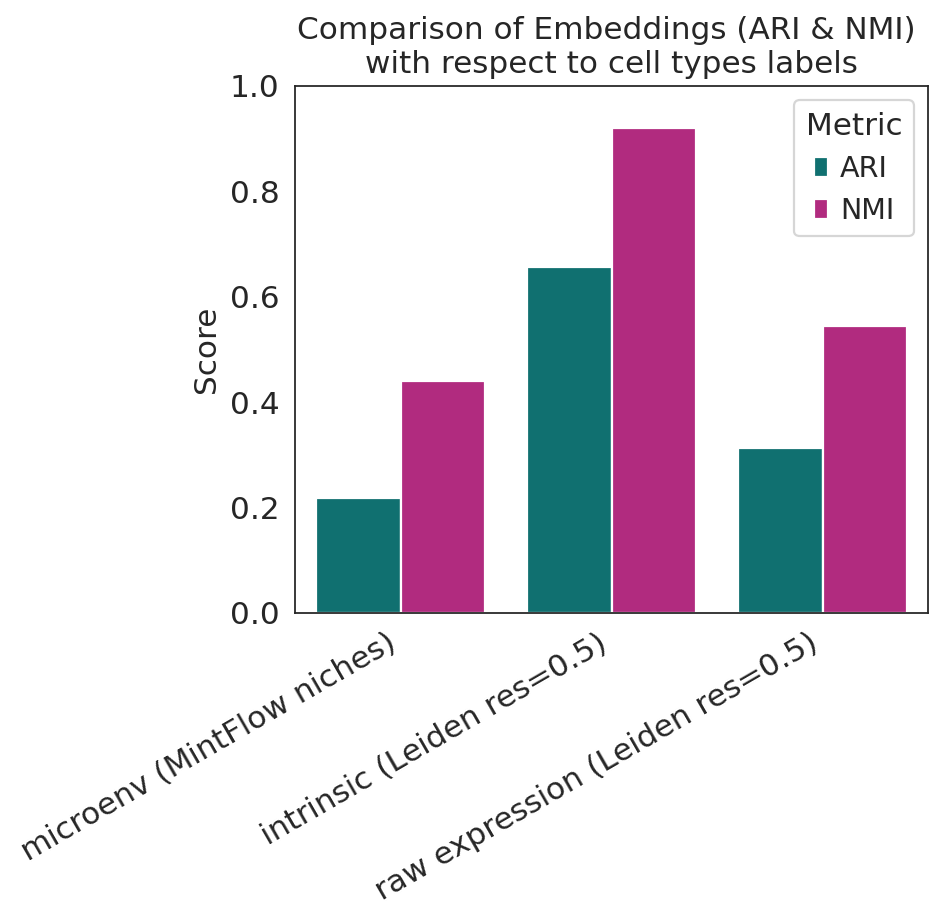

In [25]:
# If representation is an index, reset it first
df = df_ari_nmi.reset_index()

# Convert to long format
df_long = df.melt(
    id_vars="embedding",
    value_vars=["ARI", "NMI"],
    var_name="Metric",
    value_name="Score"
)

# Plot
plt.figure(figsize=(6, 6))

# Custom colors
palette = {
    "ARI": "#008080",      # acquamarine
    "NMI": "#C71585"       # magenta
}

sns.set_style("white")
sns.despine()
sns.barplot(
    data=df_long,
    x="embedding",
    y="Score",
    hue="Metric",
    palette=palette
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.title("Comparison of Embeddings (ARI & NMI) \nwith respect to cell types labels")
plt.tight_layout()
plt.show()

In [26]:
cell_type_key = "spatial_niche" 

def ari_nmi(obs_a, obs_b):
    a = obs_a.astype(str).values
    b = obs_b.astype(str).values
    return {
        "ARI": adjusted_rand_score(a, b),
        "NMI": normalized_mutual_info_score(a, b),
    }

scores_ct = []

# microenvironment clusters (MintFlow niches)
scores_ct.append({
    "embedding": "microenv (MintFlow niches)",
    **ari_nmi(adata_sub.obs[cell_type_key], adata_sub.obs["mintflow_spatial_niche"])
})

# intrinsic clusters
scores_ct.append({
    "embedding": "intrinsic (Leiden res=0.5)",
    **ari_nmi(adata_sub.obs[cell_type_key], adata_sub.obs["leiden_intrinsic_res0.5"])
})

# raw expression clusters (from adata_X)
scores_ct.append({
    "embedding": "raw expression (Leiden res=0.5)",
    **ari_nmi(adataX_sub.obs[cell_type_key], adataX_sub.obs["leiden_expression_res0.5"])
})

df_ari_nmi = pd.DataFrame(scores_ct)
df_ari_nmi

,embedding,ARI,NMI
0,microenv (MintFlow niches),1.000000,1.000000
1,intrinsic (Leiden res=0.5),0.111419,0.401529
2,raw expression (Leiden res=0.5),0.420051,0.498622


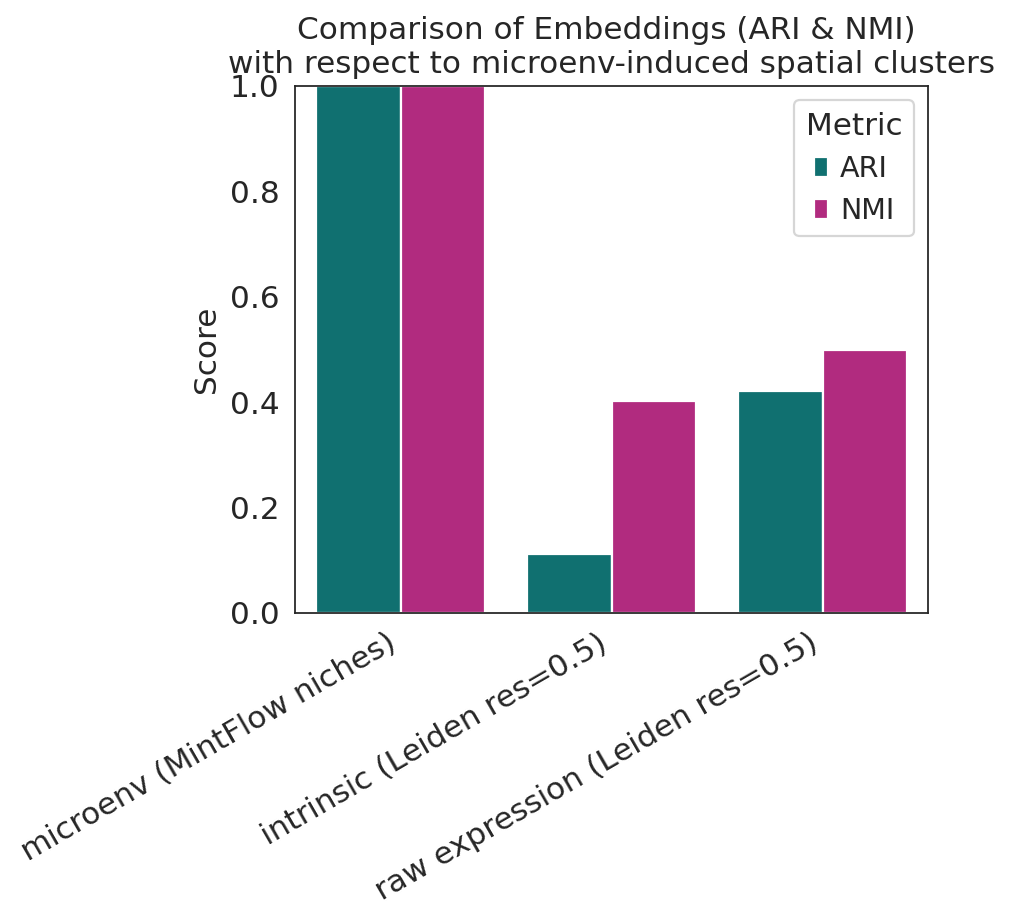

In [27]:
# If representation is an index, reset it first
df = df_ari_nmi.reset_index()

# Convert to long format
df_long = df.melt(
    id_vars="embedding",
    value_vars=["ARI", "NMI"],
    var_name="Metric",
    value_name="Score"
)

# Plot
plt.figure(figsize=(6, 6))

# Custom colors
palette = {
    "ARI": "#008080",      # acquamarine
    "NMI": "#C71585"       # magenta
}

sns.set_style("white")
sns.despine()
sns.barplot(
    data=df_long,
    x="embedding",
    y="Score",
    hue="Metric",
    palette=palette
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.title("Comparison of Embeddings (ARI & NMI) \nwith respect to microenv-induced spatial clusters")
plt.tight_layout()
plt.show()

intrinsic: adata.obsp['connectivities', 'distances'] //

microenv: adata.obsp['neighbors_Z_connectivities', 'neighbors_Z_distances'] //

raw: adata_X.obsp['connectivities', 'distances']